In [1]:
import pandas as pd
province = pd.read_csv('data/provinces-Kmean -N.csv', usecols = ['Population', 'Area', 'Population Density'])
province.head()

,Population,Area,Population Density
0,5701394.0,1569.0,3635.0
1,372137.0,3161.0,118.0
2,284970.0,968.0,294.0
3,385053.0,4305.0,89.0
4,1553765.0,10323.0,151.0


<AxesSubplot:xlabel='Population', ylabel='Area'>

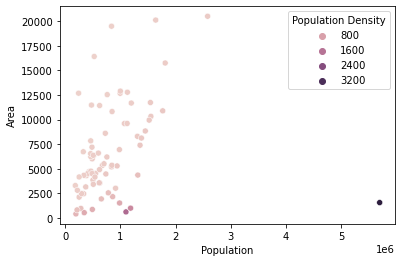

In [2]:
import seaborn as sns

sns.scatterplot(data = province, x = 'Population', y = 'Area', hue = 'Population Density')

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(province[['Population', 'Area']], province[['Population Density']], test_size=0.3, random_state=0)

In [4]:
from sklearn import preprocessing

X_train_norm = preprocessing.normalize(X_train)
X_test_norm = preprocessing.normalize(X_test)

In [5]:
X_train_norm

array([[9.99971172e-01, 7.59306587e-03],
       [9.99972809e-01, 7.37438671e-03],
       [9.99983923e-01, 5.67038882e-03],
       [9.99918598e-01, 1.27591788e-02],
       [9.99977930e-01, 6.64371522e-03],
       [9.99978677e-01, 6.53030518e-03],
       [9.99921790e-01, 1.25065345e-02],
       [9.99994231e-01, 3.39682919e-03],
       [9.99968504e-01, 7.93673437e-03],
       [9.99994507e-01, 3.31459336e-03],
       [9.99984184e-01, 5.62424746e-03],
       [9.99952510e-01, 9.74567684e-03],
       [9.99710143e-01, 2.40754945e-02],
       [9.99915162e-01, 1.30257258e-02],
       [9.99998429e-01, 1.77276210e-03],
       [9.99963926e-01, 8.49387718e-03],
       [9.99981575e-01, 6.07046693e-03],
       [9.99916972e-01, 1.28859943e-02],
       [9.99929927e-01, 1.18380961e-02],
       [9.99970217e-01, 7.71779698e-03],
       [9.99937978e-01, 1.11373357e-02],
       [9.99960033e-01, 8.94053199e-03],
       [9.99985156e-01, 5.44861085e-03],
       [9.99999841e-01, 5.64559885e-04],
       [9.998647

In [6]:
from sklearn.cluster import KMeans

In [7]:
kmeans = KMeans(n_clusters = 3)

In [8]:
kmeans

KMeans(n_clusters=3)

In [9]:
kmeans.fit(X_train_norm)

KMeans(n_clusters=3)

<AxesSubplot:xlabel='Population', ylabel='Area'>

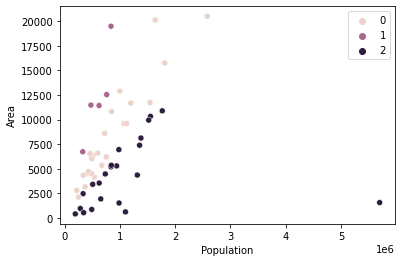

In [10]:
sns.scatterplot(data = X_train, x = 'Population', y = 'Area', hue = kmeans.labels_)

<AxesSubplot:ylabel='Population Density'>

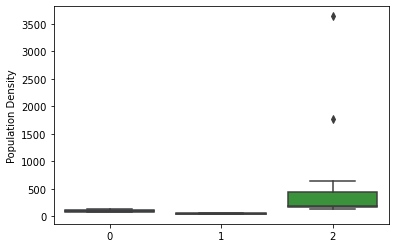

In [11]:
sns.boxplot(x = kmeans.labels_, y = y_train['Population Density'])

In [12]:
from sklearn.metrics import silhouette_score

silhouette_score(X_train_norm, kmeans.labels_, metric='euclidean')

0.5244730583266144

In [13]:
K = range(2, 8)
fits = []
score = []


for k in K:
    model = KMeans(n_clusters = k).fit(X_train_norm)
    
    fits.append(model)
    
    score.append(silhouette_score(X_train_norm, model.labels_, metric='euclidean'))

<AxesSubplot:xlabel='Population', ylabel='Area'>

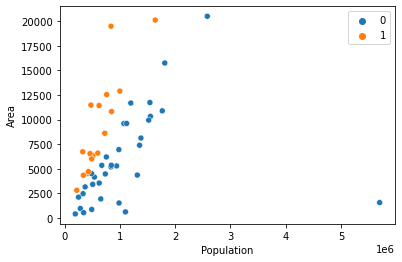

In [14]:
sns.scatterplot(data = X_train, x = 'Population', y = 'Area', hue = fits[0].labels_)

<AxesSubplot:xlabel='Population', ylabel='Area'>

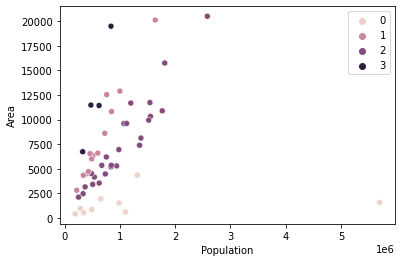

In [15]:
sns.scatterplot(data = X_train, x = 'Population', y = 'Area', hue = fits[2].labels_)

<AxesSubplot:xlabel='Population', ylabel='Area'>

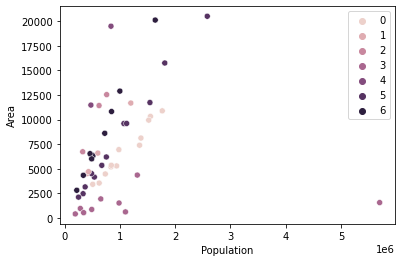

In [16]:
sns.scatterplot(data = X_train, x = 'Population', y = 'Area', hue = fits[5].labels_)

<AxesSubplot:>

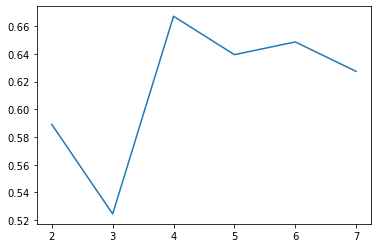

In [17]:
sns.lineplot(x = K, y = score)